In [1]:
# --- Cell 1: imports, GPU check, basic setup ---

import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# Use double precision – safer for near‑critical q
dtype = torch.float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("Torch version:", torch.__version__)


Device: cuda
Torch version: 2.9.0+cu126


In [2]:
# --- Cell 2: q-Racah BD rates and Hamiltonian (batched, GPU) ---

def qracah_params(qs, N, device=device, dtype=dtype):
    """
    Given a 1D tensor of q-values (0<q<1) and integer N,
    construct (a,b,c,d,tilde_d) tensors satisfying the q-Racah constraints:

        c = q^{-N}
        0 < d < 1
        0 < a < q^N d
        q d < b < 1
        a <= b

    Here we use a simple admissible parametrisation common to all q:

        d = 0.5
        a = 0.5 * q^N * d
        b = 0.75      (works for all q in (0,1))
    """
    qs = torch.as_tensor(qs, device=device, dtype=dtype)  # shape (K,)
    assert torch.all((qs > 0) & (qs < 1)), "This implementation assumes 0 < q < 1."

    # Broadcast to (K,1)
    qs_col = qs.unsqueeze(1)

    d = torch.tensor(0.5, device=device, dtype=dtype)          # scalar
    c = qs_col ** (-N)                                         # (K,1)
    a = 0.5 * (qs_col ** N) * d                                # (K,1), 0<a<q^N d
    b = torch.tensor(0.75, device=device, dtype=dtype)         # scalar, q d < b < 1

    # \tilde{d} = a b c d^{-1} q^{-1}
    tilde_d = (a * b * c) / (d * qs_col)                       # (K,1)

    return a, b, c, d, tilde_d, qs_col


def qracah_bd_rates_batch(qs, N, device=device, dtype=dtype):
    """
    Batched q-Racah birth/death rates B(x), D(x) for all q in `qs` on lattice X={0,...,N}.

    Implements equations (4.44)-(4.45) of Sasaki (2022):
        B(x) = - (1 - a q^x)(1 - b q^x)(1 - c q^x)(1 - d q^x)
                   / [(1 - d q^{2x})(1 - d q^{2x+1})]
        D(x) = - \tilde{d} (1 - a^{-1} d q^x)(1 - b^{-1} d q^x)(1 - c^{-1} d q^x)(1 - q^x)
                   / [(1 - d q^{2x-1})(1 - d q^{2x})]

    Returns:
        B, D: tensors of shape (K, N+1)
    """
    qs = torch.as_tensor(qs, device=device, dtype=dtype)
    K = qs.shape[0]

    a, b, c, d, tilde_d, qs_col = qracah_params(qs, N, device=device, dtype=dtype)

    # x indices 0..N as row vector (1, N+1)
    x = torch.arange(0, N + 1, device=device, dtype=dtype).unsqueeze(0)  # (1, N+1)

    # Powers of q: broadcasting (K,1) ** (1,N+1) -> (K, N+1)
    qx   = qs_col ** x           # q^x
    q2x  = qs_col ** (2 * x)     # q^{2x}
    q2xm1 = qs_col ** (2 * x - 1)  # q^{2x-1}

    # Numerators and denominators
    num_B = (1 - a * qx) * (1 - b * qx) * (1 - c * qx) * (1 - d * qx)
    den_B = (1 - d * q2x) * (1 - d * q2x * qs_col)  # q^{2x+1} = q^{2x} * q

    num_D = (1 - (d / a) * qx) * (1 - (d / b) * qx) * (1 - (d / c) * qx) * (1 - qx)
    den_D = (1 - d * q2xm1) * (1 - d * q2x)

    B = - num_B / den_B
    D = - tilde_d * num_D / den_D

    # Enforce reflecting boundaries: D(0)=0, B(N)=0
    B[:, -1] = 0.0
    D[:,  0] = 0.0

    return B, D


def make_qracah_H_batch(qs, N, device=device, dtype=dtype):
    """
    Build the symmetric Hamiltonians H(q) for all q in `qs`.

    Uses the standard BD -> symmetric transform (eq. (3.19)):
        H_{x,x}   = B(x) + D(x)
        H_{x,x+1} = H_{x+1,x} = -sqrt(B(x) D(x+1))
    """
    B, D = qracah_bd_rates_batch(qs, N, device=device, dtype=dtype)
    K, Np1 = B.shape[0], B.shape[1]

    H = torch.zeros((K, Np1, Np1), device=device, dtype=dtype)

    idx = torch.arange(Np1, device=device)
    H[:, idx, idx] = B + D  # diagonal

    off = -torch.sqrt(B[:, :-1] * D[:, 1:])  # (K, N)
    i = torch.arange(N, device=device)
    H[:, i, i + 1] = off
    H[:, i + 1, i] = off

    return H


def qracah_gaps_batch(N, qs, device=device, dtype=dtype):
    """
    Compute mass gaps m_q(N) for all q in `qs` by diagonalising H(q) on the GPU.

    We use torch.linalg.eigvalsh (batched) and take the smallest positive eigenvalue
    (E0 ~ 0 from BD structure, E1 is the gap).
    """
    qs = torch.as_tensor(qs, device=device, dtype=dtype)
    H = make_qracah_H_batch(qs, N, device=device, dtype=dtype)

    # Batched symmetric eigenvalues: shape (K, N+1)
    evals = torch.linalg.eigvalsh(H)
    evals = torch.sort(evals, dim=-1).values  # ascending along last axis

    # First eigenvalue should be ~0; take the next one as the gap
    # (if numerical noise makes E0 slightly positive, this still picks the smallest)
    gaps = evals[:, 1]

    return gaps.detach().cpu().numpy()


Running q-Racah mass gaps for N=300, 40 q-values on cuda...
q= 0.800   m_q(N=300) = -3.633496e+10
q= 0.805   m_q(N=300) = -2.675701e+09
q= 0.810   m_q(N=300) = -1.172659e+09
q= 0.815   m_q(N=300) = -5.125278e+08
q= 0.819   m_q(N=300) = -4.536633e+07
q= 0.824   m_q(N=300) = -4.387079e+06
q= 0.829   m_q(N=300) = -4.618058e+05
q= 0.834   m_q(N=300) = -9.593716e+05
q= 0.839   m_q(N=300) = -2.632519e+04
q= 0.844   m_q(N=300) = -3.284654e+03
q= 0.849   m_q(N=300) = -4.291562e+02
q= 0.854   m_q(N=300) = -5.679930e+01
q= 0.858   m_q(N=300) = -7.040373e+00
q= 0.863   m_q(N=300) = -6.172446e-01
q= 0.868   m_q(N=300) = -5.462318e-02
q= 0.873   m_q(N=300) = -4.704810e-02
q= 0.878   m_q(N=300) = -4.393227e-02
q= 0.883   m_q(N=300) = -4.094747e-02
q= 0.888   m_q(N=300) = 7.898319e-02
q= 0.893   m_q(N=300) = 1.267750e-01
q= 0.897   m_q(N=300) = 7.359434e-02
q= 0.902   m_q(N=300) = 7.637069e-02
q= 0.907   m_q(N=300) = 6.394885e-02
q= 0.912   m_q(N=300) = 6.026848e-02
q= 0.917   m_q(N=300) = 5.662752e-

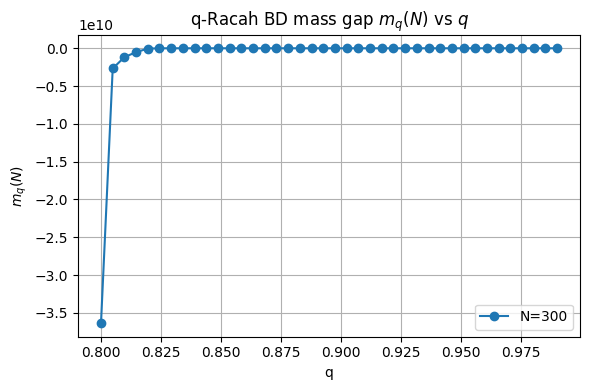

In [3]:
# --- Cell 3: scan m_q(N) vs q at fixed N ---

# Lattice size
N = 300  # bump this upward (e.g. 600, 800) to really load the A100

# q-grid on (0,1), approaching 1 from below
q_min, q_max, num_q = 0.80, 0.99, 40
q_vals = np.linspace(q_min, q_max, num_q, dtype=np.float64)

print(f"Running q-Racah mass gaps for N={N}, {num_q} q-values on {device}...")

gaps = qracah_gaps_batch(N, q_vals, device=device, dtype=dtype)

for q, m in zip(q_vals, gaps):
    print(f"q={q:6.3f}   m_q(N={N}) = {m:.6e}")

# Plot
plt.figure(figsize=(6,4))
plt.plot(q_vals, gaps, "o-", label=f"N={N}")
plt.xlabel("q")
plt.ylabel(r"$m_q(N)$")
plt.title(r"q-Racah BD mass gap $m_q(N)$ vs $q$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Computing near-critical gaps for N=400...
Effective exponent nu_eff ≈ 1.029270


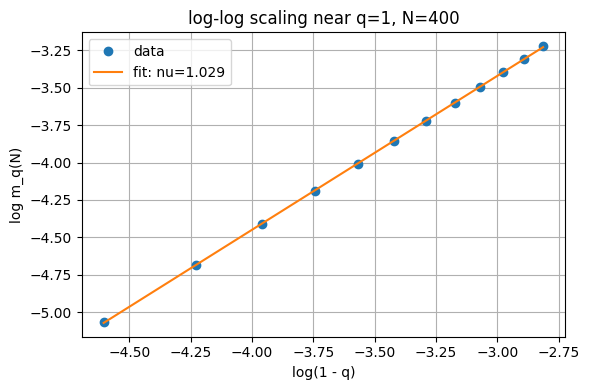

In [4]:
# --- Cell 4: extract an effective exponent nu from m_q(N) ~ (1-q)^nu ---

# Choose a (possibly larger) N for near-critical scaling
N_crit = 400  # you can push this higher (e.g. 800) once it's stable

# Very close to q=1 from below
q_vals_crit = np.linspace(0.94, 0.99, 12, dtype=np.float64)

print(f"Computing near-critical gaps for N={N_crit}...")
gaps_crit = qracah_gaps_batch(N_crit, q_vals_crit, device=device, dtype=dtype)

# Distance to critical point
x = 1.0 - q_vals_crit

# Only keep entries with positive gap and x>0
mask = (gaps_crit > 0) & (x > 0)
x_fit = x[mask]
m_fit = gaps_crit[mask]

# Log–log fit: log m ~ nu * log(1-q) + const
log_x = np.log(x_fit)
log_m = np.log(m_fit)
coef = np.polyfit(log_x, log_m, 1)
slope, intercept = coef[0], coef[1]
nu_est = slope  # since log m ≈ nu * log(1-q) + const

print(f"Effective exponent nu_eff ≈ {nu_est:.6f}")

# Plot the log-log data and fit
plt.figure(figsize=(6,4))
plt.plot(log_x, log_m, "o", label="data")
plt.plot(
    log_x,
    slope * log_x + intercept,
    "-",
    label=f"fit: nu={nu_est:.3f}"
)
plt.xlabel("log(1 - q)")
plt.ylabel("log m_q(N)")
plt.title(f"log-log scaling near q=1, N={N_crit}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
